# Technical Note P2: NumPy Array, Shape, Axis

**Wook Kang · Revised English edition · Version 1.0.0 · 3 October 2026**

This note connects a mathematical task to a numerical object, an implementation, and evidence about the result. It is an instructional computational document. Demonstration parameters are illustrative unless explicitly stated otherwise.

Run from a fresh kernel in cell order. See [the series README](../README.md) for setup and [editorial and verification notes](../docs/EDITORIAL_NOTES.md) for scope and limitations. The English prose has been reorganized and expanded from the supplied Korean notebook; this is an adapted edition rather than a line-by-line translation.

**Reading question:** What is given, what is unknown, what operation relates them, and what independent check can assess the output?

In [1]:
# Reproducible display and scale-aware comparison.
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
def scaled_allclose(a, b, rtol=1e-12, atol=None, **kwargs):
    """Compare numerical examples using an absolute tolerance scaled to b."""
    a, b = np.asarray(a), np.asarray(b)
    scale = float(np.max(np.abs(b))) if b.size else 0.0
    if atol is None:
        atol = 1e-14 * max(scale, np.finfo(float).tiny)
    return np.allclose(a, b, rtol=rtol, atol=atol, **kwargs)


## 1. The ndarray

An ndarray combines data with shape, dtype, strides, and storage. Shape describes index structure; it does not by itself identify the physical quantity.

```python
numpy.ndarray
```

In [2]:
import numpy as np

a = np.array([1.0, 2.0, 3.0])

print("a =", a)
print("type(a) =", type(a))
print("shape =", a.shape)
print("ndim =", a.ndim)
print("size =", a.size)
print("dtype =", a.dtype)

a = [1. 2. 3.]
type(a) = <class 'numpy.ndarray'>
shape = (3,)
ndim = 1
size = 3
dtype = float64


## 2. Shape

Shape lists the length of each axis. Read each entry together with its declared meaning, such as coordinate, sample, time, or component.

```python
A.shape == (3, 4)
```

$$
\boxed{
3\times4
}
$$

In [3]:
A = np.arange(12).reshape(3, 4)

print(A)
print("shape =", A.shape)
print("ndim =", A.ndim)
print("size =", A.size)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
shape = (3, 4)
ndim = 2
size = 12


## 3. Number of axes

Ndim counts storage axes. It is independent of physical spatial dimension and of the tensor order of the stored quantity.

```python
(Nx, Ny, Nz, 3)
```

In [4]:
scalar_field_3d = np.zeros((10, 20, 30))
vector_field_3d = np.zeros((10, 20, 30, 3))

print("3D scalar field ndim =", scalar_field_3d.ndim)
print("3D vector field ndim =", vector_field_3d.ndim)

3D scalar field ndim = 3
3D vector field ndim = 4


## 4. Scalars

A zero-dimensional ndarray has shape (). A Python float and a NumPy scalar-like object can play similar numerical roles but have different interfaces.

$$
T=25.0
$$

```python
T = 25.0
```

In [5]:
T_python = 25.0
T_numpy0d = np.array(25.0)

print(type(T_python), T_python)
print(type(T_numpy0d), T_numpy0d)
print("0D shape =", T_numpy0d.shape)
print("0D ndim =", T_numpy0d.ndim)

<class 'float'> 25.0
<class 'numpy.ndarray'> 25.0
0D shape = ()
0D ndim = 0


```python
()
```

## 5. Vectors with shape (n,)

A one-dimensional array holds components or samples. It is neither a row nor a column matrix until a second axis is introduced.

$$
\mathbf v=
\begin{bmatrix}
v_1\\
v_2\\
v_3
\end{bmatrix}
$$

```python
v.shape == (3,)
```

In [6]:
v = np.array([1.0, 2.0, 3.0])

print(v)
print("shape =", v.shape)
print("ndim =", v.ndim)

[1. 2. 3.]
shape = (3,)
ndim = 1


```python
(3,)
```

## 6. Three different vector shapes

Shapes (3,), (3,1), and (1,3) behave differently under broadcasting and matrix multiplication. Choose the interface deliberately rather than reshaping to silence an error.

$$
(3,)
\neq
(3,1)
\neq
(1,3)
$$

In [7]:
v1 = np.array([1, 2, 3])
v_col = np.array([[1], [2], [3]])
v_row = np.array([[1, 2, 3]])

print("v1    shape =", v1.shape)
print("v_col shape =", v_col.shape)
print("v_row shape =", v_row.shape)

v1    shape = (3,)
v_col shape = (3, 1)
v_row shape = (1, 3)


## 7. Matrices

A two-axis array can represent a linear map or a table of samples. Specify which meaning applies before using transpose or matrix multiplication.

$$
\mathbf A=
\begin{bmatrix}
a_{11} & a_{12}\\
a_{21} & a_{22}
\end{bmatrix}
$$

In [8]:
A = np.array([
    [1.0, 2.0],
    [3.0, 4.0],
])

print(A)
print("shape =", A.shape)
print("ndim =", A.ndim)

[[1. 2.]
 [3. 4.]]
shape = (2, 2)
ndim = 2


## 8. Axis

An axis is an index direction in storage. For reductions, axis identifies the dimensions to collapse, not the dimensions to retain.

```python
A.shape == (3,4)
```

```python
U.shape == (Nx, Ny, Nz)
```

In [9]:
U = np.zeros((4, 5, 6))

print("shape =", U.shape)
for ax, n in enumerate(U.shape):
    print(f"axis {ax}: length = {n}")

shape = (4, 5, 6)
axis 0: length = 4
axis 1: length = 5
axis 2: length = 6


## 9. A one-dimensional scalar field

Store sampled values with their coordinate array. Node values and cell averages have different locations and require different quadrature and boundary treatment.

$$
u(x)
$$

$$
u_i=u(x_i)
$$

```python
U.shape == (Nx,)
```

In [10]:
Nx = 8
U1 = np.linspace(0.0, 1.0, Nx)

print("U1 =", U1)
print("shape =", U1.shape)

U1 = [0.         0.14285714 0.28571429 0.42857143 0.57142857 0.71428571
 0.85714286 1.        ]
shape = (8,)


## 10. A two-dimensional scalar field

For the ij convention used here, U[i,j] corresponds to x[i], y[j]. Plotting libraries commonly use a row-column convention, so an explicit transpose may be needed.

$$
u(x,y)
$$

$$
u_{ij}=u(x_i,y_j)
$$

```python
U.shape == (Nx, Ny)
```

In [11]:
Nx, Ny = 4, 6
U2 = np.zeros((Nx, Ny))

print(U2)
print("shape =", U2.shape)

[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]
shape = (4, 6)


```python
U2[i, j]
```

$$
u(x_i,y_j)
$$

## 11. A three-dimensional scalar field

Declare U.shape=(Nx,Ny,Nz) and keep coordinates in the same order. Memory cost grows with the product of all axis lengths.

$$
u(x,y,z)
$$

$$
u_{ijk}
$$

```python
U.shape == (Nx, Ny, Nz)
```

In [12]:
Nx, Ny, Nz = 4, 5, 3
U3 = np.zeros((Nx, Ny, Nz))

print("shape =", U3.shape)
print("U3[2,3,1] =", U3[2, 3, 1])

shape = (4, 5, 3)
U3[2,3,1] = 0.0


## 12. A three-dimensional vector field

Use the last axis for components: V.shape=(Nx,Ny,Nz,3). A spatial index selects a point, and the remaining axis selects the vector component.

$$
\mathbf v(x,y,z)
=
\begin{bmatrix}
v_x\\
v_y\\
v_z
\end{bmatrix}
$$

```python
V.shape == (Nx, Ny, Nz, 3)
```

In [13]:
Nx, Ny, Nz = 4, 5, 3
V = np.zeros((Nx, Ny, Nz, 3))

print("shape =", V.shape)
print("vector at one point =", V[1, 2, 0, :])

shape = (4, 5, 3, 3)
vector at one point = [0. 0. 0.]


```python
V[i,j,k,0] -> v_x
V[i,j,k,1] -> v_y
V[i,j,k,2] -> v_z
```

$$
\boxed{
\text{spatial axes}
+
\text{component axis}
}
$$

## 13. Separate component arrays

A stacked field and separate vx, vy, vz arrays are both useful. Choose one internal convention and convert at a clear interface.

```python
vx.shape == (Nx,Ny,Nz)
vy.shape == (Nx,Ny,Nz)
vz.shape == (Nx,Ny,Nz)
```

In [14]:
vx = np.zeros((4, 5, 3))
vy = np.zeros((4, 5, 3))
vz = np.zeros((4, 5, 3))

print(vx.shape, vy.shape, vz.shape)

(4, 5, 3) (4, 5, 3) (4, 5, 3)


## 14. Tensor fields

A second-order tensor field in three dimensions can have shape (Nx,Ny,Nz,3,3). The first axes locate the sample; the last two index tensor components.

$$
\boldsymbol\sigma(x,y,z)
$$

```python
sigma.shape == (Nx, Ny, Nz, 3, 3)
```

In [15]:
sigma = np.zeros((4, 5, 3, 3, 3))

print("shape =", sigma.shape)
print("tensor at one point:")
print(sigma[1, 2, 0])

shape = (4, 5, 3, 3, 3)
tensor at one point:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


$$
\boxed{
(i,j,k,\alpha,\beta)
}
$$

## 15. Dtype

Dtype controls representation and precision. Integer arrays cannot safely hold general derivative values or NaN sentinels; floating-point arithmetic remains approximate.

In [16]:
a = np.array([1, 2, 3])
b = np.array([1.0, 2.0, 3.0])
c = np.array([True, False, True])

print(a.dtype)
print(b.dtype)
print(c.dtype)

int64
float64
bool


```python
float64
```

In [17]:
U = np.zeros((3, 3), dtype=float)
print(U.dtype)

float64


## 16. Array construction

Use zeros, ones, full, array, and related constructors to express initialization clearly. Avoid relying on uninitialized values from empty.

```python
np.array
np.zeros
np.ones
np.full
np.arange
np.linspace
np.empty
```

In [18]:
print("zeros :", np.zeros(4))
print("ones  :", np.ones(4))
print("full  :", np.full(4, 0.25))
print("arange:", np.arange(0, 5, 1))
print("linspace:", np.linspace(0, 1, 5))

zeros : [0. 0. 0. 0.]
ones  : [1. 1. 1. 1.]
full  : [0.25 0.25 0.25 0.25]
arange: [0 1 2 3 4]
linspace: [0.   0.25 0.5  0.75 1.  ]


```python
np.linspace
np.arange
```

## 17. Arange and linspace

Arange specifies a step and excludes the stop; floating-point steps can complicate endpoint reasoning. Linspace specifies a count and includes the endpoint unless requested otherwise.

In [19]:
x1 = np.arange(0.0, 1.0, 0.2)
x2 = np.linspace(0.0, 1.0, 6)

print("arange  :", x1)
print("linspace:", x2)

arange  : [0.  0.2 0.4 0.6 0.8]
linspace: [0.  0.2 0.4 0.6 0.8 1. ]


## 18. Nodes and cell centres

N nodes spanning a closed interval have spacing L/(N-1). N equal cells have width L/N, N centres, and N+1 faces.

$$
0\le x\le L
$$

$$
\Delta x=\frac{L}{N}
$$

$$
x_i=\left(i+\frac12\right)\Delta x
$$

In [20]:
L = 1.0
N = 5
dx = L / N

x_center = (np.arange(N) + 0.5) * dx

print("dx =", dx)
print("cell centers =", x_center)

dx = 0.2
cell centers = [0.1 0.3 0.5 0.7 0.9]


## 19. Size and degrees of freedom

Size counts stored entries. It equals the unknown count only when all entries are independent unknowns; constrained and boundary values may not be solved for.

```python
U.shape == (Nx,Ny,Nz)
```

$$
N_{\mathrm{dof}}=
N_xN_yN_z
$$

In [21]:
Nx, Ny, Nz = 20, 30, 10
U = np.zeros((Nx, Ny, Nz))

print("shape =", U.shape)
print("size =", U.size)
print("product =", Nx*Ny*Nz)

shape = (20, 30, 10)
size = 6000
product = 6000


$$
(i,j,k)
\leftrightarrow
I
$$

## 20. Inspect shape before debugging arithmetic

Print shape, ndim, dtype, and finite-value information at interfaces. A compatible shape can still encode the wrong physical axis.

```python
print(A.shape)
print(x.shape)
print(b.shape)
```

In [22]:
A = np.eye(3)
x = np.array([1.0, 2.0, 3.0])

print("A.shape =", A.shape)
print("x.shape =", x.shape)
print("(A @ x).shape =", (A @ x).shape)

A.shape = (3, 3)
x.shape = (3,)
(A @ x).shape = (3,)


## 21. Reshape

Reshape reinterprets a linear ordering without performing a physical interpolation. Confirm the flattening order before mapping an array to solver unknowns.

$$
(12,)
\rightarrow
(3,4)
$$

In [23]:
a = np.arange(12)
A = a.reshape(3, 4)

print("a =", a)
print("A =")
print(A)

a = [ 0  1  2  3  4  5  6  7  8  9 10 11]
A =
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


$$
12=3\times4
$$

## 22. Ravel and flatten

Ravel returns a view when possible and otherwise a copy; flatten always copies. Whether a reshape shares memory depends on strides and layout.

```python
U.shape == (Nx,Ny)
```

$$
U_{ij}
\rightarrow
\mathbf u_I
$$

In [24]:
U = np.arange(12).reshape(3, 4)

u = U.ravel()

print("U shape =", U.shape)
print("u shape =", u.shape)
print(u)

U shape = (3, 4)
u shape = (12,)
[ 0  1  2  3  4  5  6  7  8  9 10 11]


$$
A\mathbf u=\mathbf b
$$

$$
\boxed{
\text{field array}
\leftrightarrow
\text{global unknown vector}
}
$$

## 23. Restore a field from a vector

Use the same shape and order in both directions. A round-trip check tests storage consistency, not the correctness of the underlying physical discretization.

In [25]:
shape = (3, 4)
u = np.arange(12)

U = u.reshape(shape)

print(U)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


$$
\boxed{
U_{ij}
\leftrightarrow
u_I
}
$$

## 24. Reductions along an axis

Sum or mean removes the selected axis. Decide whether the operation represents a count, arithmetic mean, integral, or weighted physical average.

```python
np.mean(A, axis=0)
np.mean(A, axis=1)
```

In [26]:
A = np.array([
    [1., 2., 3.],
    [4., 5., 6.],
])

print("A =")
print(A)
print("mean all =", np.mean(A))
print("mean axis=0 =", np.mean(A, axis=0))
print("mean axis=1 =", np.mean(A, axis=1))

A =
[[1. 2. 3.]
 [4. 5. 6.]]
mean all = 3.5
mean axis=0 = [2.5 3.5 4.5]
mean axis=1 = [2. 5.]


```python
(2,3) -> (3,)
```

```python
(2,3) -> (2,)
```

## 25. Means of three-dimensional fields

Reducing axis 2 averages over the stored z index under this convention. Nonuniform samples require appropriate weights for a spatial mean.

```python
U.shape == (Nx,Ny,Nz)
```

```python
np.mean(U, axis=2)
```

```python
(Nx,Ny)
```

In [27]:
U = np.random.default_rng(0).random((4, 5, 6))

Uz_mean = np.mean(U, axis=2)

print("U shape =", U.shape)
print("z-mean shape =", Uz_mean.shape)

U shape = (4, 5, 6)
z-mean shape = (4, 5)


$$
\bar u(x,y)=
\frac{1}{L_z}
\int u(x,y,z)\,dz
$$

## 26. Keepdims

Keepdims retains reduced axes with length one. This often makes subsequent broadcasting explicit and avoids accidental axis matching.

```python
keepdims=True
```

In [28]:
A = np.arange(12).reshape(3, 4)

m1 = A.mean(axis=1)
m2 = A.mean(axis=1, keepdims=True)

print("m1 shape =", m1.shape)
print("m2 shape =", m2.shape)

m1 shape = (3,)
m2 shape = (3, 1)


## 27. Insert a singleton axis

None or newaxis adds an axis of length one without creating new physical samples. Use it to declare the intended broadcasting relationship.

```python
x.shape == (N,)
```

```python
(N,1)
```

In [29]:
x = np.array([1., 2., 3.])

x_col = x[:, np.newaxis]
x_row = x[np.newaxis, :]

print("x      :", x.shape)
print("x_col  :", x_col.shape)
print("x_row  :", x_row.shape)

x      : (3,)
x_col  : (3, 1)
x_row  : (1, 3)


## 28. Meshgrid

Use indexing='ij' when axis 0 is x and axis 1 is y. The default xy convention changes the first two output axes.

$$
u(x,y)
$$

In [30]:
x = np.linspace(0, 1, 4)
y = np.linspace(0, 2, 3)

X, Y = np.meshgrid(x, y, indexing="ij")

print("x shape =", x.shape)
print("y shape =", y.shape)
print("X shape =", X.shape)
print("Y shape =", Y.shape)

print("X =")
print(X)
print("Y =")
print(Y)

x shape = (4,)
y shape = (3,)
X shape = (4, 3)
Y shape = (4, 3)
X =
[[0.         0.         0.        ]
 [0.33333333 0.33333333 0.33333333]
 [0.66666667 0.66666667 0.66666667]
 [1.         1.         1.        ]]
Y =
[[0. 1. 2.]
 [0. 1. 2.]
 [0. 1. 2.]
 [0. 1. 2.]]


```python
X.shape == (Nx,Ny)
Y.shape == (Nx,Ny)
```

$$
U_{ij}=f(X_{ij},Y_{ij})
$$

## 29. Construct a sampled field

Evaluate a mathematical function on coordinate grids. Separate coordinates, sampled values, units, and boundary assumptions.

$$
u(x,y)=
\sin(\pi x)\cos(\pi y)
$$

In [31]:
x = np.linspace(0, 1, 50)
y = np.linspace(0, 1, 40)

X, Y = np.meshgrid(x, y, indexing="ij")
U = np.sin(np.pi*X) * np.cos(np.pi*Y)

print("U shape =", U.shape)
print("min/max =", U.min(), U.max())

U shape = (50, 40)
min/max = -0.9994862162006879 0.9994862162006879


```python
U = f(X,Y)
```

$$
u(x,y)=f(x,y)
$$

$$
U_{ij}
$$

## 30. Visualize a two-dimensional field

Verify orientation using an asymmetric field and labelled axes. An attractive image cannot reveal a transposition error without a physical reference.

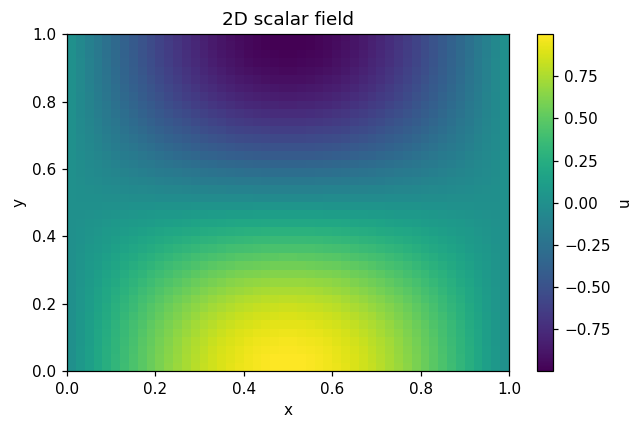

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.imshow(
    U.T,
    origin="lower",
    aspect="auto",
    extent=[x.min(), x.max(), y.min(), y.max()],
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D scalar field")
plt.colorbar(label="u")
plt.tight_layout()
plt.show()

$$
\boxed{
\text{array axis convention}
}
$$

## 31. Document shape semantics

A useful comment records both the shape and the meaning of each axis. Document component order as well as coordinate order.

```python
# U.shape = (Nx, Ny, Nz)
# last axis of V.shape = vector component [x,y,z]
```

## 32. Storage axes and tensor order

A vector field can have four storage axes but tensor order one. Tensor order concerns transformation under a basis change, not the number of ndarray axes.

$$
\sigma_{ij}
$$

```python
sigma.shape == (3,3)
```

```python
sigma.shape == (Nx,Ny,Nz,3,3)
```

$$
\boxed{
\text{tensor order}
\neq
\text{NumPy ndim}
}
$$

## 33. Three kinds of dimension

Distinguish spatial dimension, component dimension, and storage dimension. Time histories and batches add storage axes without changing tensor order.

| Concept | Example |  
| --- | --- |  
| Physical dimension | 3D space |  
| Component dimension | vector 3, tensor 3×3 |  
| Storage dimension | ndarray ndim |

```python
V.shape = (Nx,Ny,Nz,3)
```

## 34. Estimate memory

Multiply the entry count by bytes per entry, then allow for temporaries and saved histories. A modest-looking grid can become expensive when time and component axes are added.

```python
(100,100,100)
```

$$
8\times10^6\text{ bytes}
$$

In [33]:
shape = (100, 100, 100)
U = np.zeros(shape, dtype=np.float64)

print("elements =", U.size)
print("bytes =", U.nbytes)
print("MB =", U.nbytes / 1024**2)

elements = 1000000
bytes = 8000000
MB = 7.62939453125


## 35. Nbytes

Nbytes measures the array's element storage. It does not include all Python-object overhead or the peak memory used by a calculation.

```python
array.nbytes
```

## 36. Views and copies

Check whether an operation aliases existing storage before modifying its output. The next note develops this distinction with indexing examples.

```python
B = A
```

## 37. Shape mismatch as useful evidence

A mismatch exposes an interface inconsistency. Repair the mathematical mapping before inserting arbitrary reshapes or transposes.

$$
A\in\mathbb R^{2\times3},
\qquad
x\in\mathbb R^4
$$

$$
Ax
$$

In [34]:
A = np.zeros((2, 3))
x = np.zeros(4)

print("A shape =", A.shape)
print("x shape =", x.shape)

try:
    y = A @ x
except ValueError as e:
    print("Expected shape error:")
    print(e)

A shape = (2, 3)
x shape = (4,)
Expected shape error:
matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 4 is different from 3)


## 38. Think through shapes first

Write expected input and output shapes on paper. This makes contractions, reductions, and broadcasting easier to verify.

```python
x      : (Nx,)
y      : (Ny,)
X, Y   : (Nx,Ny)
U      : (Nx,Ny)
gradU  : ?
V      : (Nx,Ny,2)
```

## 39. Object-to-shape map

A scalar has no component axis; vectors have one; second-order tensors have two. Prefix them with location, time, or batch axes as required.

| Mathematical or physical object | Example NumPy shape |  
| --- | --- |  
| scalar | `()` or Python scalar |  
| vector | `(n,)` |  
| matrix | `(m,n)` |  
| 1D scalar field | `(Nx,)` |  
| 2D scalar field | `(Nx,Ny)` |  
| 3D scalar field | `(Nx,Ny,Nz)` |  
| 2D vector field | `(Nx,Ny,2)` |  
| 3D vector field | `(Nx,Ny,Nz,3)` |  
| 3D tensor field | `(Nx,Ny,Nz,3,3)` |  
| flattened field | `(Nx*Ny*Nz,)` |

## 40. Six ideas to retain

Declare axis semantics, distinguish storage from tensor order, track dtype, handle endpoint conventions, maintain flattening order, and budget memory.

## 41. Continue to P3

Indexing and broadcasting determine which points and components participate in each operation. They translate spatial relationships into array expressions.

$$
\boxed{
\text{interior}
\quad
\text{boundary}
\quad
\text{neighbor}
}
$$

## Further work

1. Change one parameter or discretization choice and predict the effect before running.
2. Write the input and output shapes, units, and field locations.
3. Construct a deliberately invalid input and make the calculation report it clearly.
4. Separate an execution check from an accuracy check and from any physical claim.

## Primary documentation

- [NumPy user guide](https://numpy.org/doc/stable/user/)

These are living documentation links. The accompanying requirements and verification report identify the versions actually executed for this edition.

## AI assistance and responsibility

The English adaptation, editorial supplementation, and code review were prepared with AI assistance. Wook Kang retains responsibility for reviewing the explanations, examples, and any subsequent research application. No new experimental validation is claimed.